In [1]:
import pandas as pd

In [2]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'energy_demand_hourly_brazil.csv', 'brazil_energy_weather.csv', 'sample_data']


In [3]:
df = pd.read_csv("energy_demand_hourly_brazil.csv")

In [4]:
df.head()

,index,hourly_demand
0,2000-01-01 00:00:00,34673.9
1,2000-01-01 01:00:00,33503.0
2,2000-01-01 02:00:00,32287.6
3,2000-01-01 03:00:00,31059.4
4,2000-01-01 04:00:00,30272.7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201318 entries, 0 to 201317
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   index          201318 non-null  object 
 1   hourly_demand  201318 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.1+ MB


In [6]:
df.describe()

,hourly_demand
count,201318.000000
mean,54391.824054
std,12211.551397
min,0.000000
25%,45169.570000
50%,53929.597000
75%,63809.801228
max,90120.004000


In [7]:
df['index'] = pd.to_datetime(df['index'])

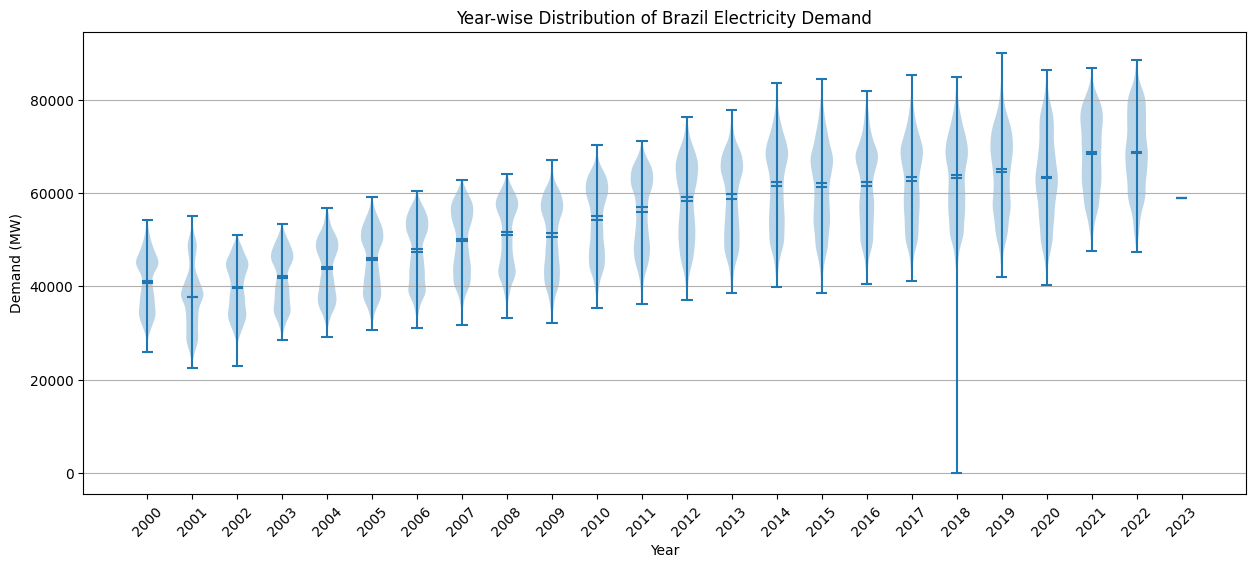

In [8]:
import matplotlib.pyplot as plt

df['year'] = df['index'].dt.year

yearly_data = [
    df[df['year'] == year]['hourly_demand']
    for year in sorted(df['year'].unique())
]

plt.figure(figsize=(15,6))

plt.violinplot(
    yearly_data,
    showmeans=True,
    showmedians=True
)

plt.xticks(
    range(1, len(sorted(df['year'].unique())) + 1),
    sorted(df['year'].unique()),
    rotation=45
)

plt.title("Year-wise Distribution of Brazil Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")

plt.grid(True, axis='y')
plt.show()

In [9]:
print(df['index'].min())
print(df['index'].max())

2000-01-01 00:00:00
2023-01-01 00:00:00


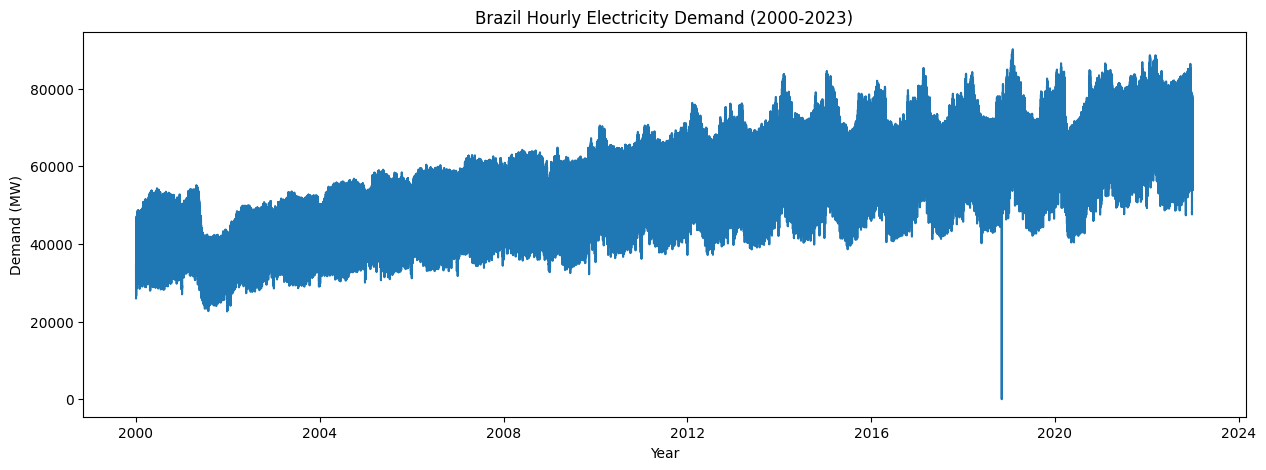

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['index'], df['hourly_demand'])
plt.title("Brazil Hourly Electricity Demand (2000-2023)")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")
plt.show()

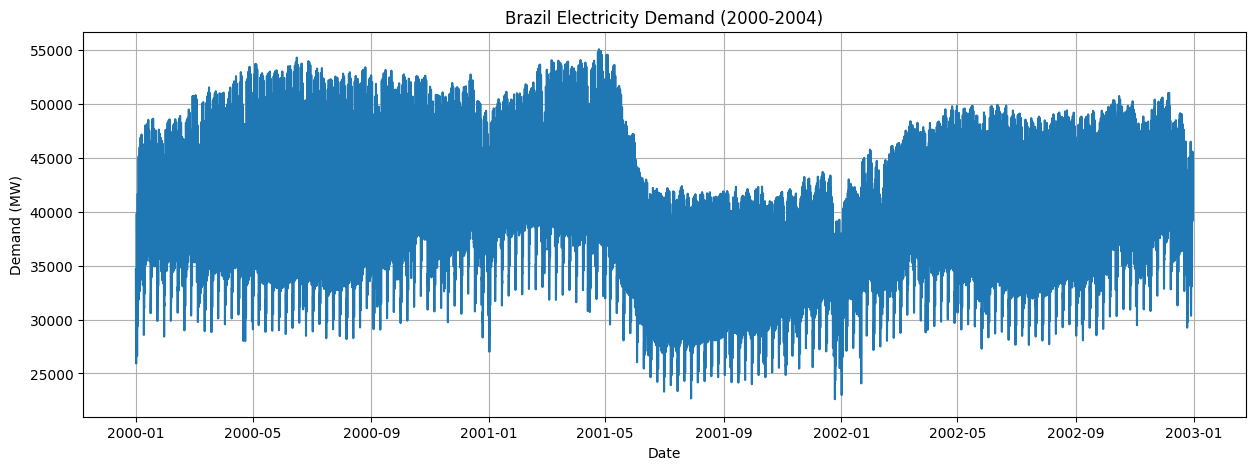

In [11]:
df_early = df[
    (df['index'] >= '2000-01-01') &
    (df['index'] <= '2002-12-31')
]

plt.figure(figsize=(15,5))
plt.plot(
    df_early['index'],
    df_early['hourly_demand']
)

plt.title("Brazil Electricity Demand (2000-2004)")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.grid(True)

plt.show()

Exploratory analysis revealed a structural break around 2001–2002, likely associated with Brazil's electricity rationing crisis. This highlights the influence of major economic and policy events on electricity demand.

In [12]:
df.isnull().sum()

,0
index,0
hourly_demand,0
year,0


In [13]:
df[df['hourly_demand'] == 0]

,index,hourly_demand,year
164861,2018-11-04,0.0,2018


In [14]:
df.loc[df['hourly_demand'] == 0, 'hourly_demand'] = None

In [15]:
df['hourly_demand'] = df['hourly_demand'].interpolate()

In [16]:
(df['hourly_demand'] == 0).sum()

np.int64(0)

In [17]:
!pip install requests

In [18]:
import requests
import pandas as pd

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=-10.02&longitude=-55.01"
    "&start_date=2000-01-01"
    "&end_date=2023-01-01"
    "&hourly=temperature_2m,relative_humidity_2m,"
    "wind_speed_10m,apparent_temperature"
    "&timezone=auto"
)

response = requests.get(url)

weather = pd.DataFrame(response.json()["hourly"])

weather.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,apparent_temperature
0,2000-01-01T00:00,23.1,96,6.4,27.4
1,2000-01-01T01:00,23.0,97,6.2,27.2
2,2000-01-01T02:00,22.8,97,3.9,27.3
3,2000-01-01T03:00,21.9,97,1.3,26.2
4,2000-01-01T04:00,21.7,98,3.5,25.7


In [19]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201648 entries, 0 to 201647
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   time                  201648 non-null  object 
 1   temperature_2m        201648 non-null  float64
 2   relative_humidity_2m  201648 non-null  int64  
 3   wind_speed_10m        201648 non-null  float64
 4   apparent_temperature  201648 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 7.7+ MB


In [20]:
df = df.rename(columns={'index':'time'})

df['time'] = pd.to_datetime(df['time'])
weather['time'] = pd.to_datetime(weather['time'])

In [21]:
merged = pd.merge(df, weather, on='time', how='inner')
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201318 entries, 0 to 201317
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   time                  201318 non-null  datetime64[ns]
 1   hourly_demand         201318 non-null  float64       
 2   year                  201318 non-null  int32         
 3   temperature_2m        201318 non-null  float64       
 4   relative_humidity_2m  201318 non-null  int64         
 5   wind_speed_10m        201318 non-null  float64       
 6   apparent_temperature  201318 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int32(1), int64(1)
memory usage: 10.0 MB


In [22]:
merged.corr(numeric_only=True)

,hourly_demand,year,temperature_2m,relative_humidity_2m,wind_speed_10m,apparent_temperature
hourly_demand,1.000000,0.761992,0.281987,-0.115279,0.035818,0.321581
year,0.761992,1.000000,0.033822,-0.023412,0.044018,0.026418
temperature_2m,0.281987,0.033822,1.000000,-0.772778,0.297614,0.850064
relative_humidity_2m,-0.115279,-0.023412,-0.772778,1.000000,-0.502463,-0.349488
wind_speed_10m,0.035818,0.044018,0.297614,-0.502463,1.000000,-0.042863
apparent_temperature,0.321581,0.026418,0.850064,-0.349488,-0.042863,1.000000


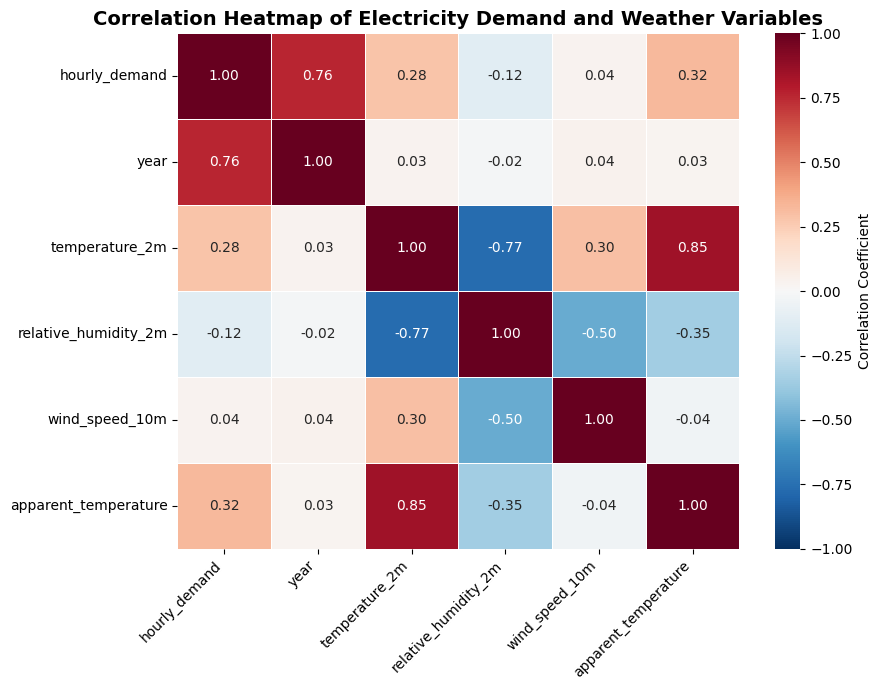

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = merged.corr(numeric_only=True)

plt.figure(figsize=(9,7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation Heatmap of Electricity Demand and Weather Variables",
          fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:

from scipy.stats import pearsonr
import pandas as pd

weather_vars = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'apparent_temperature'
]

results = []

for var in weather_vars:
    r, p = pearsonr(merged['hourly_demand'], merged[var])

    results.append({
        'Variable': var,
        'Correlation (r)': round(r, 3),
        'p-value': p,
        'Significant (α=0.05)': 'Yes' if p < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)

print(results_df)






               Variable  Correlation (r)       p-value Significant (α=0.05)
0        temperature_2m            0.282  0.000000e+00                  Yes
1  relative_humidity_2m           -0.115  0.000000e+00                  Yes
2        wind_speed_10m            0.036  3.765177e-58                  Yes
3  apparent_temperature            0.322  0.000000e+00                  Yes


In [25]:
merged.to_csv("brazil_energy_weather.csv", index=False)

In [26]:
merged = merged.set_index('time')

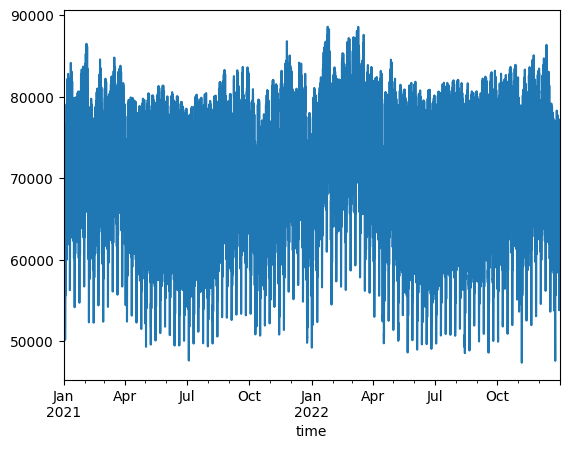

In [27]:
merged['hourly_demand']['2021-01-01':'2022-12-31'].plot()
plt.show()

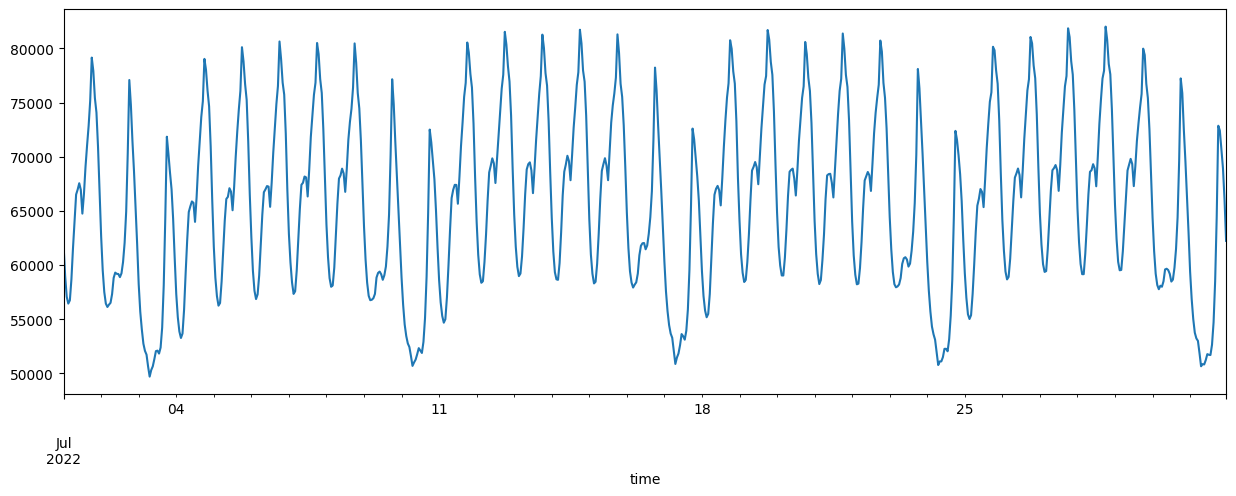

In [28]:
merged['hourly_demand']['2022-07-01':'2022-07-31'].plot(figsize=(15,5))
plt.show()

In [29]:
from statsmodels.tsa.stattools import kpss

stat, p, lags, crit = kpss(
    merged['hourly_demand'].iloc[:50000],
    regression='c'
)

print("KPSS Statistic:", stat)
print("p-value:", p)

KPSS Statistic: 17.32641919143981
p-value: 0.01


/tmp/ipykernel_1058/1952631368.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(


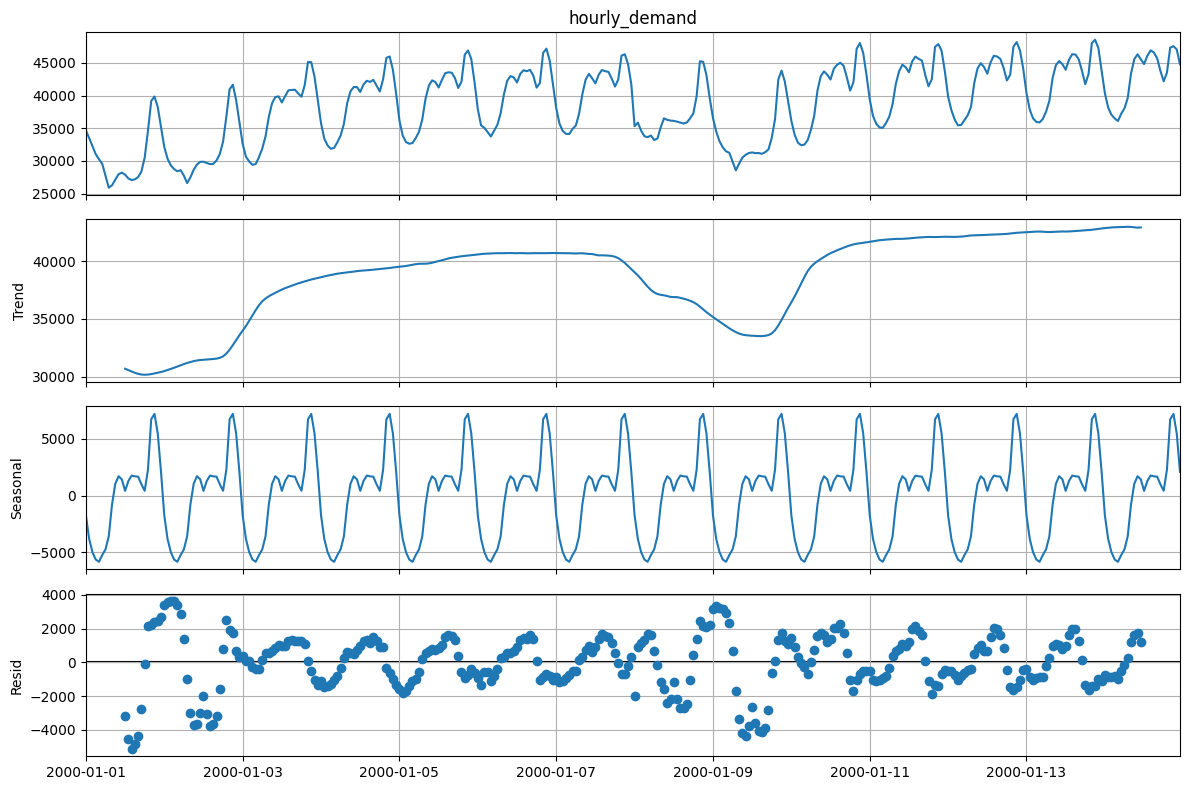

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
merged = merged.reset_index()

sample = merged.set_index('time')['hourly_demand'].iloc[:24*14]

result = seasonal_decompose(
    sample,
    model='additive',
    period=24
)

fig = result.plot()
fig.set_size_inches(12,8)

for ax in fig.axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

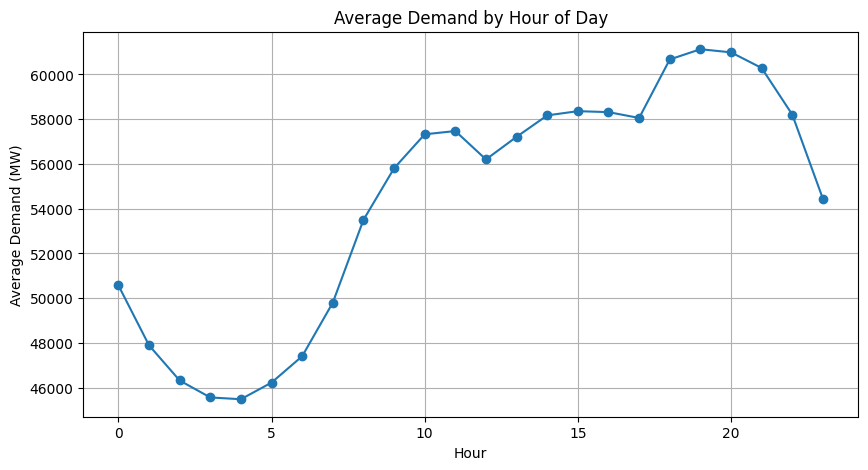

In [31]:
merged['time'] = pd.to_datetime(merged['time'])
merged = merged.set_index('time')
merged['hour'] = merged.index.hour

hourly_pattern = merged.groupby('hour')['hourly_demand'].mean()

hourly_pattern.plot(marker='o', figsize=(10,5))
plt.title("Average Demand by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Demand (MW)")
plt.grid(True)
plt.show()

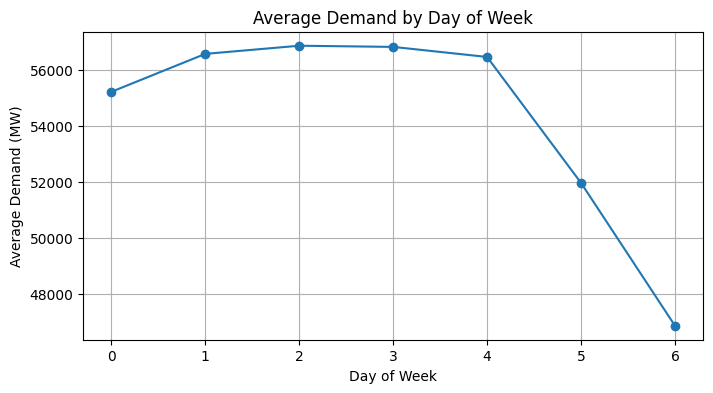

In [32]:
merged['dayofweek'] = merged.index.dayofweek

weekly_pattern = merged.groupby('dayofweek')['hourly_demand'].mean()

weekly_pattern.plot(marker='o', figsize=(8,4))
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MW)")
plt.grid(True)
plt.show()

In [33]:
# Train: 2000-2019
train = merged.loc[:'2019-12-31']

# Validation: 2020
val = merged.loc['2020-01-01':'2020-12-31']

# Test: 2021-2022
test = merged.loc['2021-01-01':'2022-12-31']

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print("\nDate ranges:")
print(train.index.min(), train.index.max())
print(val.index.min(), val.index.max())
print(test.index.min(), test.index.max())

Train: (175013, 8)
Validation: (8784, 8)
Test: (17520, 8)

Date ranges:
2000-01-01 00:00:00 2019-12-31 23:00:00
2020-01-01 00:00:00 2020-12-31 23:00:00
2021-01-01 00:00:00 2022-12-31 23:00:00


In [34]:
from sklearn.metrics import mean_absolute_percentage_error

H = len(val)

pred_naive = train['hourly_demand'].shift(24).dropna()

mape_naive = mean_absolute_percentage_error(
    train['hourly_demand'][24:],
    pred_naive
)

print("Naive MAPE:", mape_naive)

Naive MAPE: 0.06611927249964716


In [35]:
train_small = train.iloc[-20000:]

In [36]:
H = 24
VENTANA = 24 * 90    # last 90 days

train_window = merged['hourly_demand'].iloc[-(VENTANA + H):-H]

test = merged['hourly_demand'].iloc[-H:]

In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
train_window = train_window.asfreq('h')

model = SARIMAX(
    train_window,
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

results = model.fit(disp=False)

In [38]:
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      hourly_demand   No. Observations:                 2160
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -17642.546
Date:                            Fri, 03 Jul 2026   AIC                          35295.092
Time:                                    15:39:13   BIC                          35323.423
Sample:                                10-02-2022   HQIC                         35305.461
                                     - 12-31-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3188      0.011     30.287      0.000       0.298       0.339
ma.L1          0.3293      0.012   

In [39]:
sarima_forecast = results.forecast(steps=H)

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

import numpy as np

sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_forecast
)

print("SARIMA Results")
print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)
print("MAPE %:", sarima_mape * 100)

SARIMA Results
MAE : 5285.926184336456
RMSE: 6231.505444409243
MAPE: 0.09113116109159591
MAPE %: 9.113116109159591


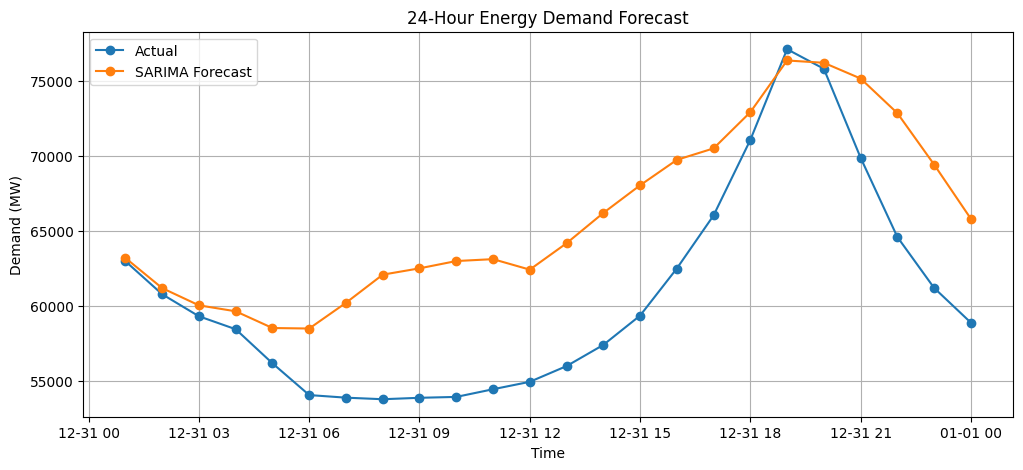

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test,
    marker='o',
    label='Actual'
)

plt.plot(
    test.index,
    sarima_forecast,
    marker='o',
    label='SARIMA Forecast'
)

plt.title("24-Hour Energy Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")

plt.legend()
plt.grid(True)

plt.show()

In [42]:
exog_cols = ['apparent_temperature']

In [43]:
train_exog = merged[exog_cols].iloc[-(2160+24):-24]
test_exog  = merged[exog_cols].iloc[-24:]

In [44]:
model_x = SARIMAX(
    train_window,
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

results_x = model_x.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [45]:
forecast_x = results_x.forecast(
    steps=24,
    exog=test_exog
)

In [46]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

mae_x = mean_absolute_error(test, forecast_x)

rmse_x = np.sqrt(
    mean_squared_error(test, forecast_x)
)

mape_x = mean_absolute_percentage_error(
    test,
    forecast_x
)

print("SARIMAX Results")
print("MAE :", mae_x)
print("RMSE:", rmse_x)
print("MAPE:", mape_x)
print("MAPE %:", mape_x * 100)

SARIMAX Results
MAE : 5266.4383090519905
RMSE: 6212.184044437599
MAPE: 0.09083016702610062
MAPE %: 9.083016702610063


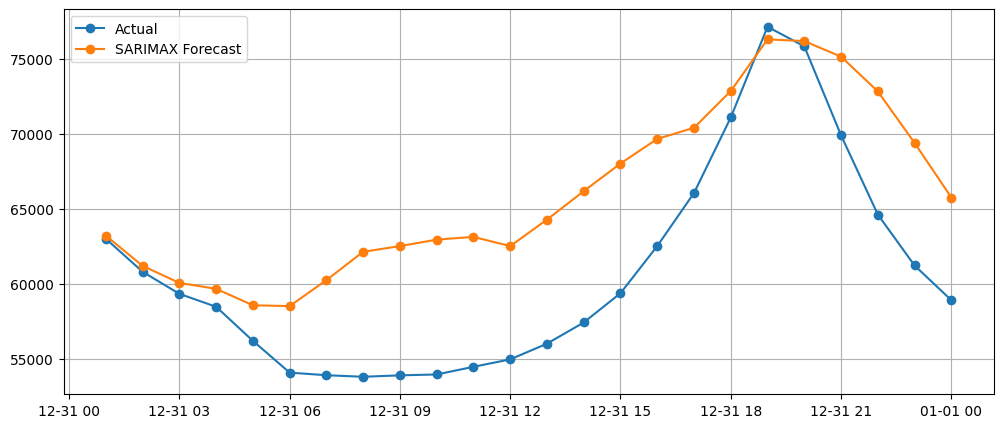

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test,
    marker='o',
    label='Actual'
)

plt.plot(
    test.index,
    forecast_x,
    marker='o',
    label='SARIMAX Forecast'
)

plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX (All Weather Variables)
MAE : 5289.857014046992
RMSE: 6235.495079286649
MAPE: 0.09123514130297579
MAPE %: 9.123514130297579


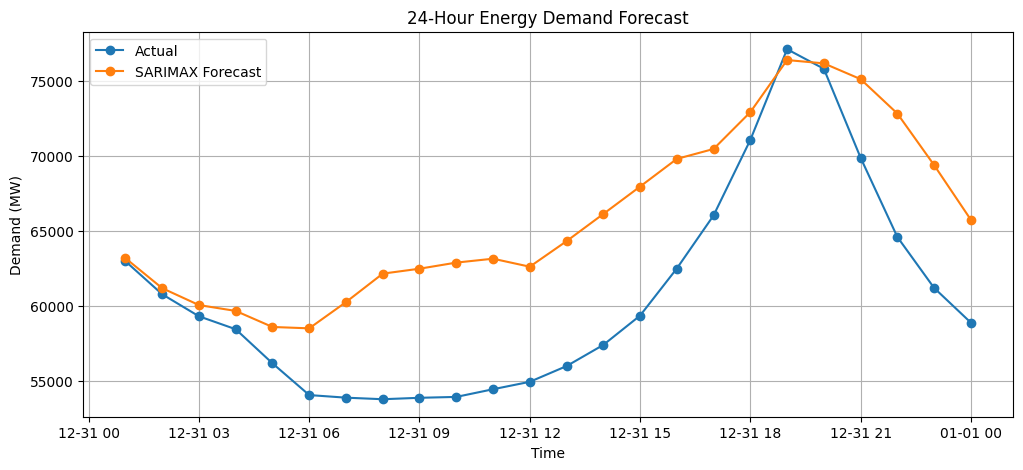

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np
import matplotlib.pyplot as plt

# Weather variables
exog_cols = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'apparent_temperature'
]

# Train/Test exogenous data
train_exog = merged[exog_cols].iloc[-(2160+24):-24]
test_exog = merged[exog_cols].iloc[-24:]

# Fit SARIMAX
model_x = SARIMAX(
    train_window,
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

results_x = model_x.fit(disp=False)

# Forecast next 24 hours
forecast_x = results_x.forecast(
    steps=24,
    exog=test_exog
)

# Metrics
mae_x = mean_absolute_error(test, forecast_x)

rmse_x = np.sqrt(
    mean_squared_error(test, forecast_x)
)

mape_x = mean_absolute_percentage_error(
    test,
    forecast_x
)

print("SARIMAX (All Weather Variables)")
print("MAE :", mae_x)
print("RMSE:", rmse_x)
print("MAPE:", mape_x)
print("MAPE %:", mape_x * 100)

# Plot
plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test,
    marker='o',
    label='Actual'
)

plt.plot(
    test.index,
    forecast_x,
    marker='o',
    label='SARIMAX Forecast'
)

plt.title("24-Hour Energy Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

print(torch.cuda.is_available())

True


In [50]:
df = merged.reset_index().copy()

df["time"] = pd.to_datetime(df["time"])

# Use recent years for faster training
df = df[df["time"].dt.year >= 2018].reset_index(drop=True)

df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["dow_sin"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["day_of_week"]/7)

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

feature_cols = [
    "hourly_demand",
    "hour_sin","hour_cos",
    "dow_sin","dow_cos",
    "month_sin","month_cos",
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "apparent_temperature"
]

df = df[["time"] + feature_cols]

In [51]:
n = len(df)

train_end = int(n * 0.7)
val_end = int(n * 0.8)

train_data = df.iloc[:train_end]
val_data = df.iloc[train_end:val_end]
test_data = df.iloc[val_end:]

print(train_data.shape)
print(val_data.shape)
print(test_data.shape)

(30677, 12)
(4383, 12)
(8765, 12)


In [52]:
demand_scaler = StandardScaler()
feature_scaler = StandardScaler()

train_demand = demand_scaler.fit_transform(
    train_data[["hourly_demand"]]
)

val_demand = demand_scaler.transform(
    val_data[["hourly_demand"]]
)

test_demand = demand_scaler.transform(
    test_data[["hourly_demand"]]
)

other_cols = feature_cols[1:]

train_feat = feature_scaler.fit_transform(
    train_data[other_cols]
)

val_feat = feature_scaler.transform(
    val_data[other_cols]
)

test_feat = feature_scaler.transform(
    test_data[other_cols]
)

train_scaled = np.hstack([train_demand, train_feat])
val_scaled = np.hstack([val_demand, val_feat])
test_scaled = np.hstack([test_demand, test_feat])

In [53]:
SEQ_LEN = 24 * 3

def make_sequences(data, seq_len):

    X = []
    y = []

    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len,0])

    return (
        np.array(X,dtype=np.float32),
        np.array(y,dtype=np.float32).reshape(-1,1)
    )

X_train,y_train = make_sequences(
    train_scaled,
    SEQ_LEN
)

X_val,y_val = make_sequences(
    np.vstack([train_scaled[-SEQ_LEN:],val_scaled]),
    SEQ_LEN
)

X_test,y_test = make_sequences(
    np.vstack([val_scaled[-SEQ_LEN:],test_scaled]),
    SEQ_LEN
)

print(X_train.shape)
print(X_test.shape)

(30605, 72, 11)
(8765, 72, 11)


In [54]:
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train)
    ),
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val),
        torch.tensor(y_val)
    ),
    batch_size=128
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test),
        torch.tensor(y_test)
    ),
    batch_size=128
)

In [55]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [56]:
class RNNModel(nn.Module):

    def __init__(self,input_size):

        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        out,_ = self.rnn(x)

        return self.fc(out[:,-1,:])

In [57]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

rnn = RNNModel(
    input_size=X_train.shape[2]
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    rnn.parameters(),
    lr=0.001
)

epochs = 10

train_losses = []
val_losses = []

for epoch in range(epochs):

    # TRAINING
    rnn.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = rnn(X_batch)

        loss = criterion(
            output,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    rnn.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = rnn(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1 | Train Loss: 0.1075 | Val Loss: 0.0314
Epoch 2 | Train Loss: 0.0332 | Val Loss: 0.0295
Epoch 3 | Train Loss: 0.0232 | Val Loss: 0.0256
Epoch 4 | Train Loss: 0.0182 | Val Loss: 0.0187
Epoch 5 | Train Loss: 0.0145 | Val Loss: 0.0245
Epoch 6 | Train Loss: 0.0122 | Val Loss: 0.0182
Epoch 7 | Train Loss: 0.0113 | Val Loss: 0.0129
Epoch 8 | Train Loss: 0.0106 | Val Loss: 0.0113
Epoch 9 | Train Loss: 0.0097 | Val Loss: 0.0115
Epoch 10 | Train Loss: 0.0089 | Val Loss: 0.0114


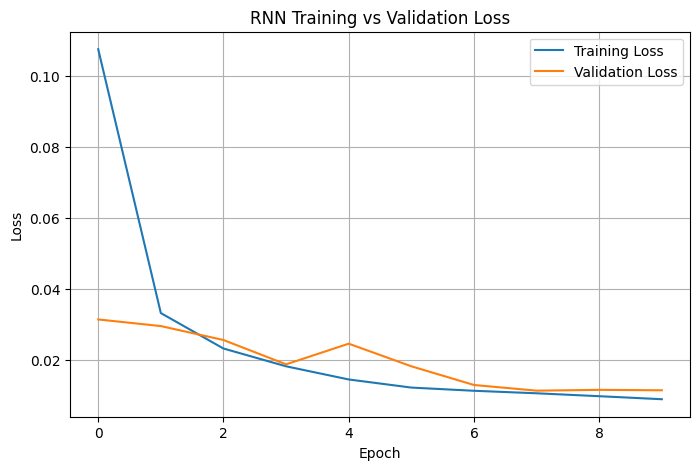

In [58]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [59]:
rnn.eval()

rnn_preds = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        output = rnn(X_batch)

        rnn_preds.append(
            output.cpu().numpy()
        )

rnn_preds = np.concatenate(rnn_preds)

rnn_preds = demand_scaler.inverse_transform(
    rnn_preds
)

actual_rnn = demand_scaler.inverse_transform(
    y_test
)

mae = mean_absolute_error(
    actual_rnn,
    rnn_preds
)

rmse = np.sqrt(
    mean_squared_error(
        actual_rnn,
        rnn_preds
    )
)

mape = mean_absolute_percentage_error(
    actual_rnn,
    rnn_preds
)

print("RNN Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape * 100)

RNN Results
MAE : 924.9856567382812
RMSE: 1269.3027121218956
MAPE: 1.3299296610057354


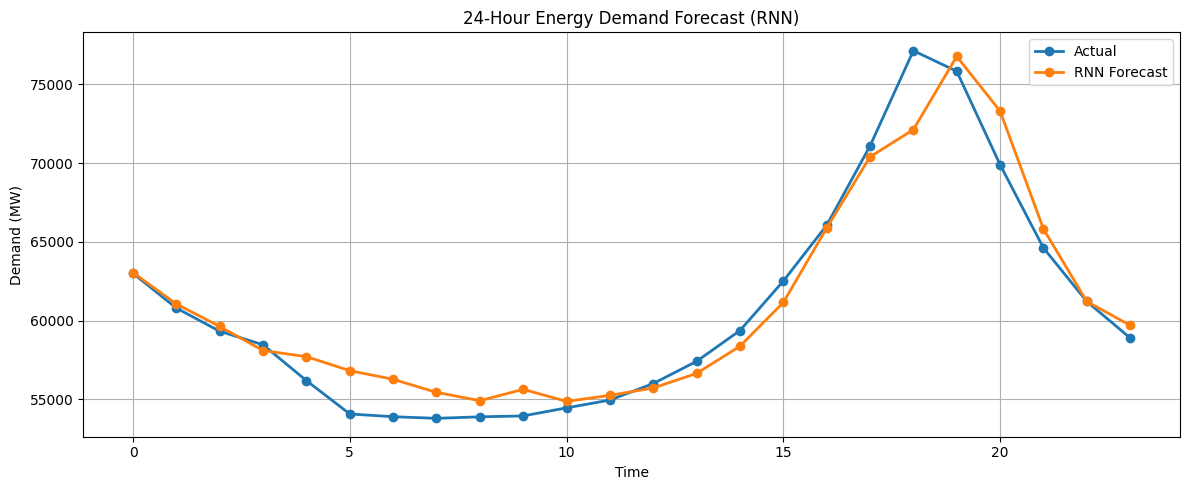

In [60]:





import matplotlib.pyplot as plt

# Last 24-hour forecast horizon
actual_24 = actual_rnn[-24:]
pred_24   = rnn_preds[-24:]

plt.figure(figsize=(12,5))

plt.plot(actual_24,
         label='Actual',
         marker='o',
         linewidth=2)

plt.plot(pred_24,
         label='RNN Forecast',
         marker='o',
         linewidth=2)

plt.title('24-Hour Energy Demand Forecast (RNN)')
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [61]:
class LSTMModel(nn.Module):

    def __init__(self,input_size):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        return self.fc(out[:,-1,:])

In [62]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

lstm = LSTMModel(
    input_size=X_train.shape[2]
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm.parameters(),
    lr=0.001
)

epochs = 10

lstm_train_losses = []
lstm_val_losses = []

for epoch in range(epochs):

    lstm.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = lstm(X_batch)

        loss = criterion(
            output,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    lstm.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = lstm(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1 | Train Loss: 0.1575 | Val Loss: 0.0667
Epoch 2 | Train Loss: 0.0432 | Val Loss: 0.0596
Epoch 3 | Train Loss: 0.0327 | Val Loss: 0.0415
Epoch 4 | Train Loss: 0.0240 | Val Loss: 0.0243
Epoch 5 | Train Loss: 0.0179 | Val Loss: 0.0154
Epoch 6 | Train Loss: 0.0143 | Val Loss: 0.0118
Epoch 7 | Train Loss: 0.0124 | Val Loss: 0.0132
Epoch 8 | Train Loss: 0.0107 | Val Loss: 0.0104
Epoch 9 | Train Loss: 0.0096 | Val Loss: 0.0087
Epoch 10 | Train Loss: 0.0086 | Val Loss: 0.0069


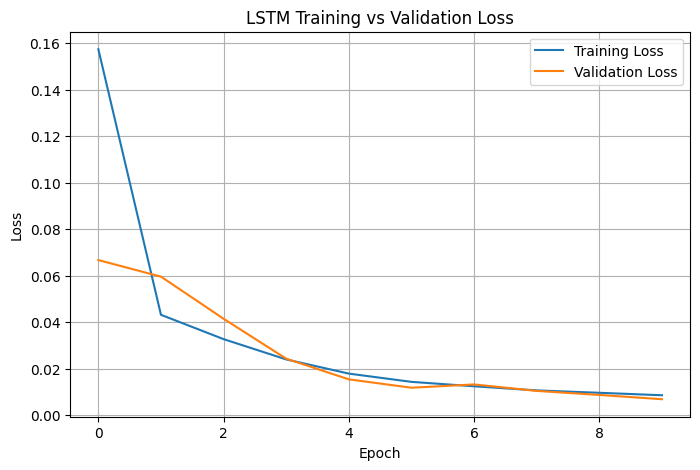

In [63]:
plt.figure(figsize=(8,5))

plt.plot(
    lstm_train_losses,
    label="Training Loss"
)

plt.plot(
    lstm_val_losses,
    label="Validation Loss"
)

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [64]:
lstm.eval()

lstm_preds = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        output = lstm(X_batch)

        lstm_preds.append(
            output.cpu().numpy()
        )

lstm_preds = np.concatenate(lstm_preds)

lstm_preds = demand_scaler.inverse_transform(
    lstm_preds
)

actual_lstm = demand_scaler.inverse_transform(
    y_test
)

lstm_mae = mean_absolute_error(
    actual_lstm,
    lstm_preds
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_lstm,
        lstm_preds
    )
)

lstm_mape = mean_absolute_percentage_error(
    actual_lstm,
    lstm_preds
)

print("LSTM Results")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape * 100)

LSTM Results
MAE : 772.5003051757812
RMSE: 997.1888925875578
MAPE: 1.139279268682003


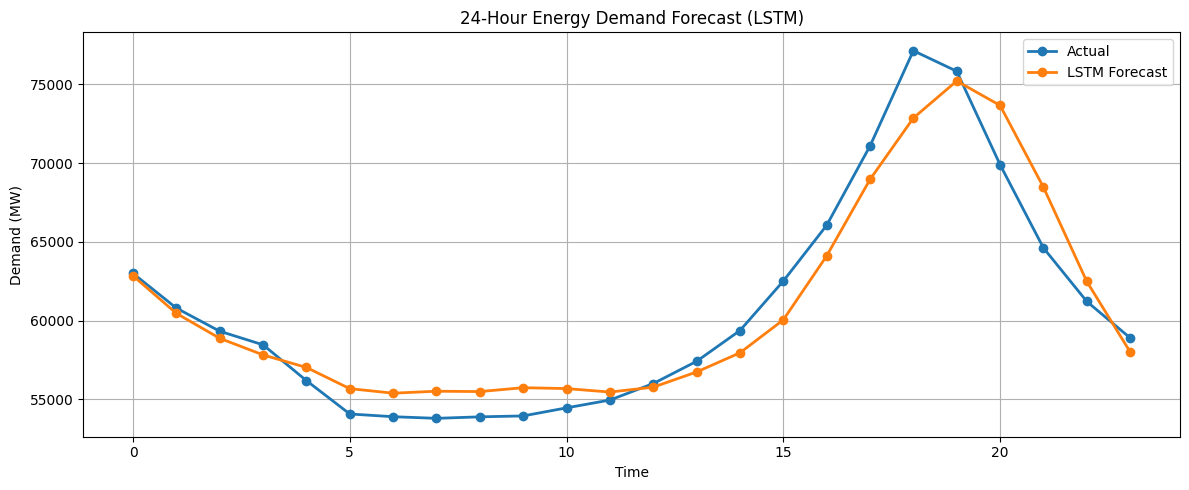

In [65]:
import matplotlib.pyplot as plt

# Last 24-hour forecast horizon
actual_24 = actual_lstm[-24:]
pred_24   = lstm_preds[-24:]

plt.figure(figsize=(12,5))

plt.plot(actual_24,
         label='Actual',
         marker='o',
         linewidth=2)

plt.plot(pred_24,
         label='LSTM Forecast',
         marker='o',
         linewidth=2)

plt.title('24-Hour Energy Demand Forecast (LSTM)')
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [66]:
print(
    "Average Difference Between RNN and LSTM Predictions:",
    np.mean(np.abs(rnn_preds - lstm_preds))
)

Average Difference Between RNN and LSTM Predictions: 803.1806


In [67]:
comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "MAE": [mae, lstm_mae],
    "RMSE": [rmse, lstm_rmse],
    "MAPE (%)": [mape*100, lstm_mape*100]
})

print(comparison)

  Model         MAE         RMSE  MAPE (%)
0   RNN  924.985657  1269.302712  1.329930
1  LSTM  772.500305   997.188893  1.139279


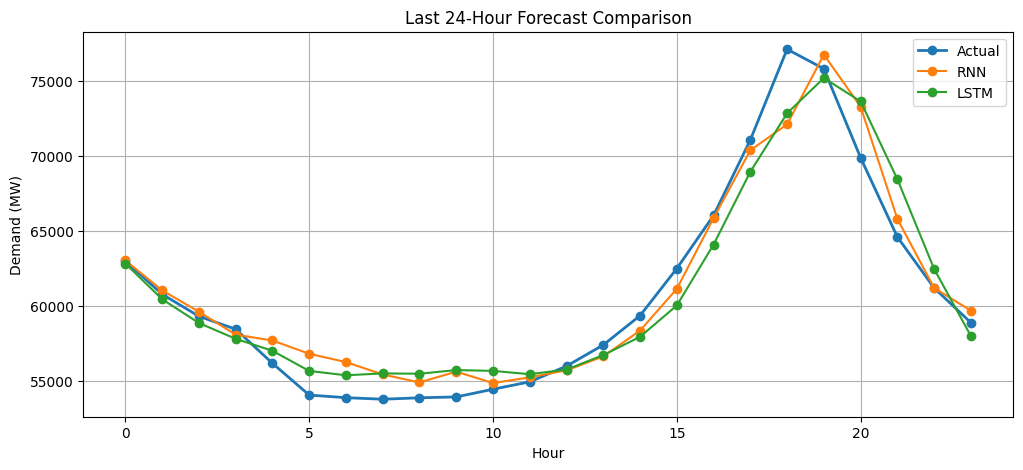

In [68]:
plt.figure(figsize=(12,5))

plt.plot(
    actual_lstm[-24:],
    marker='o',
    linewidth=2,
    label='Actual'
)

plt.plot(
    rnn_preds[-24:],
    marker='o',
    label='RNN'
)

plt.plot(
    lstm_preds[-24:],
    marker='o',
    label='LSTM'
)

plt.title("Last 24-Hour Forecast Comparison")
plt.xlabel("Hour")
plt.ylabel("Demand (MW)")

plt.legend()
plt.grid(True)

plt.show()

In [69]:
print("test:", len(test))
print("forecast_x:", len(forecast_x))
print("rnn:", len(rnn_preds[-24:]))
print("lstm:", len(lstm_preds[-24:]))

test: 24
forecast_x: 24
rnn: 24
lstm: 24


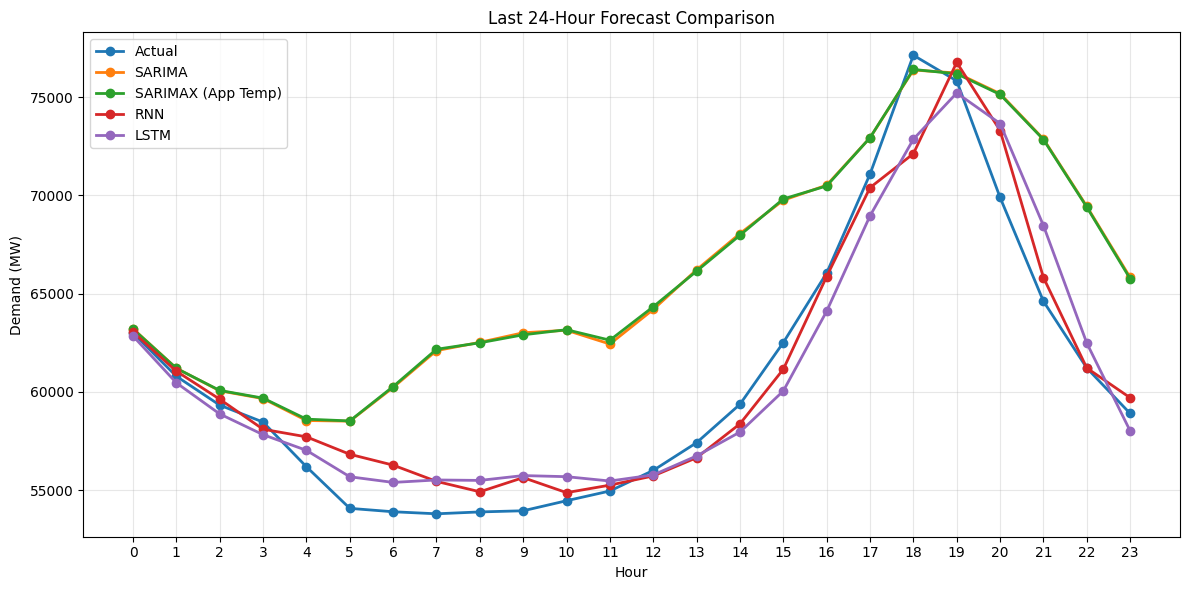

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Last 24-hour forecasts
actual_24  = np.asarray(actual_rnn[-24:]).ravel()
sarima_24  = np.asarray(sarima_forecast).ravel()
sarimax_24 = np.asarray(forecast_x).ravel()      # SARIMAX (Apparent Temperature)
rnn_24     = np.asarray(rnn_preds[-24:]).ravel()
lstm_24    = np.asarray(lstm_preds[-24:]).ravel()

hours = np.arange(24)

plt.figure(figsize=(12,6))

plt.plot(hours, actual_24,  marker='o', linewidth=2, label='Actual')
plt.plot(hours, sarima_24,  marker='o', linewidth=2, label='SARIMA')
plt.plot(hours, sarimax_24, marker='o', linewidth=2, label='SARIMAX (App Temp)')
plt.plot(hours, rnn_24,     marker='o', linewidth=2, label='RNN')
plt.plot(hours, lstm_24,    marker='o', linewidth=2, label='LSTM')

plt.title('Last 24-Hour Forecast Comparison')
plt.xlabel('Hour')
plt.ylabel('Demand (MW)')
plt.xticks(hours)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
from scipy.stats import wilcoxon
import numpy as np

# Absolute errors
err_sarima  = np.abs(actual_24 - sarima_24)
err_sarimax = np.abs(actual_24 - sarimax_24)
err_rnn     = np.abs(actual_24 - rnn_24)
err_lstm    = np.abs(actual_24 - lstm_24)

print("=== Wilcoxon Signed-Rank Tests ===\n")

comparisons = [
    ("SARIMA vs SARIMAX", err_sarima, err_sarimax),
    ("SARIMA vs RNN", err_sarima, err_rnn),
    ("SARIMA vs LSTM", err_sarima, err_lstm),
    ("SARIMAX vs RNN", err_sarimax, err_rnn),
    ("SARIMAX vs LSTM", err_sarimax, err_lstm),
    ("RNN vs LSTM", err_rnn, err_lstm)
]

for name, e1, e2 in comparisons:

    stat, p = wilcoxon(e1, e2)

    print(name)
    print(f"W statistic = {stat:.4f}")
    print(f"p-value     = {p:.6f}")

    if p < 0.05:
        print("Result      : Significant difference (p < 0.05)")
    else:
        print("Result      : No significant difference (p ≥ 0.05)")

    print("-" * 50)

=== Wilcoxon Signed-Rank Tests ===

SARIMA vs SARIMAX
W statistic = 143.0000
p-value     = 0.855336
Result      : No significant difference (p ≥ 0.05)
--------------------------------------------------
SARIMA vs RNN
W statistic = 15.0000
p-value     = 0.000016
Result      : Significant difference (p < 0.05)
--------------------------------------------------
SARIMA vs LSTM
W statistic = 18.0000
p-value     = 0.000030
Result      : Significant difference (p < 0.05)
--------------------------------------------------
SARIMAX vs RNN
W statistic = 16.0000
p-value     = 0.000020
Result      : Significant difference (p < 0.05)
--------------------------------------------------
SARIMAX vs LSTM
W statistic = 18.0000
p-value     = 0.000030
Result      : Significant difference (p < 0.05)
--------------------------------------------------
RNN vs LSTM
W statistic = 86.0000
p-value     = 0.069102
Result      : No significant difference (p ≥ 0.05)
--------------------------------------------------


In [72]:
import pandas as pd

df_full = pd.read_csv(
    "energy_demand_hourly_brazil.csv"
)

df_full['index'] = pd.to_datetime(
    df_full['index']
)

print(df_full.shape)
print(df_full['index'].min())
print(df_full['index'].max())

(201318, 2)
2000-01-01 00:00:00
2023-01-01 00:00:00


In [73]:
clean_df = df_full[
    ~(
        (df_full['index'] >= '2001-05-15') &
        (df_full['index'] <= '2002-02-15')
    )
].copy()

clean_df = clean_df.reset_index(drop=True)

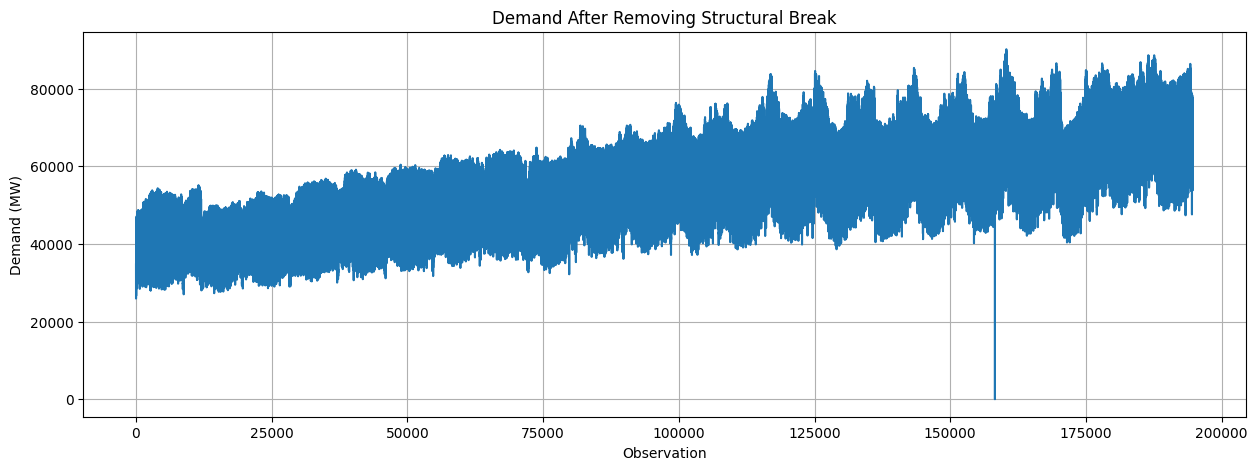

In [74]:
plt.figure(figsize=(15,5))

plt.plot(clean_df['hourly_demand'])

plt.title("Demand After Removing Structural Break")
plt.xlabel("Observation")
plt.ylabel("Demand (MW)")

plt.grid(True)
plt.show()

In [75]:
clean_df = clean_df.reset_index(drop=True)
# Replace zero demand values with NaN
clean_df['hourly_demand'] = (
    clean_df['hourly_demand']
    .replace(0, np.nan)
)

# Interpolate missing values
clean_df['hourly_demand'] = (
    clean_df['hourly_demand']
    .interpolate(method='linear')
)

# Fill any remaining edge NaNs
clean_df['hourly_demand'] = (
    clean_df['hourly_demand']
    .bfill()
    .ffill()
)

print(
    "Remaining zeros:",
    (clean_df['hourly_demand']==0).sum()
)

Remaining zeros: 0


In [76]:
clean_df = clean_df.reset_index(drop=True)
clean_df["time"] = pd.date_range(
    start="2000-01-01",
    periods=len(clean_df),
    freq="H"
)

/tmp/ipykernel_1058/962080309.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  clean_df["time"] = pd.date_range(


In [77]:
merged_clean = pd.merge(
    clean_df,
    weather,
    on="time",
    how="inner"
)

In [78]:
H = 24

train = merged_clean.iloc[:-H]
test = merged_clean.iloc[-H:]

In [79]:
exog_cols = [
    "temperature_2m"
]
train_exog = train[exog_cols]

test_exog = test[exog_cols]

In [80]:
H = 24
VENTANA = 24 * 90   # last 90 days

train_window = train["hourly_demand"].iloc[-(VENTANA + H):-H]

train_exog_window = train_exog.iloc[-(VENTANA + H):-H]

test_window = train["hourly_demand"].iloc[-H:]

test_exog_window = train_exog.iloc[-H:]

In [81]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


model_x = SARIMAX(
    train_window,
    exog=train_exog_window,
    order=(1,0,2),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_x = model_x.fit(disp=False)
forecast_x = results_x.forecast(
    steps=H,
    exog=test_exog_window
)

In [82]:
sarimax_mae = mean_absolute_error(
    test["hourly_demand"],
    forecast_x
)

sarimax_rmse = np.sqrt(
    mean_squared_error(
        test["hourly_demand"],
        forecast_x
    )
)

sarimax_mape = mean_absolute_percentage_error(
    test["hourly_demand"],
    forecast_x
)

print("MAE :", sarimax_mae)
print("RMSE:", sarimax_rmse)
print("MAPE:", sarimax_mape*100)

MAE : 6982.125839988224
RMSE: 7838.521042518777
MAPE: 11.763906124213586


In [83]:
# =========================
# PREPROCESSING FOR RNN/LSTM
# =========================

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import torch

# Features
features = [
    'hourly_demand',
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'apparent_temperature'
]

data = merged_clean[features]

# Train / Validation / Test Split
n = len(data)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

train = data.iloc[:train_size]

val = data.iloc[
    train_size:
    train_size + val_size
]

test = data.iloc[
    train_size + val_size:
]

# Scaling
feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train
)

val_scaled = feature_scaler.transform(
    val
)

test_scaled = feature_scaler.transform(
    test
)

demand_scaler = MinMaxScaler()

demand_scaler.fit(
    train[['hourly_demand']]
)

# Sequence Creation
SEQ_LEN = 72

def make_sequences(data, seq_len):

    X = []
    y = []

    for i in range(
        len(data) - seq_len
    ):

        X.append(
            data[i:i+seq_len]
        )

        y.append(
            data[i+seq_len,0]
        )

    return (
        np.array(
            X,
            dtype=np.float32
        ),
        np.array(
            y,
            dtype=np.float32
        ).reshape(-1,1)
    )

X_train, y_train = make_sequences(
    train_scaled,
    SEQ_LEN
)

X_val, y_val = make_sequences(
    np.vstack([
        train_scaled[-SEQ_LEN:],
        val_scaled
    ]),
    SEQ_LEN
)

X_test, y_test = make_sequences(
    np.vstack([
        val_scaled[-SEQ_LEN:],
        test_scaled
    ]),
    SEQ_LEN
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

# DataLoaders
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train)
    ),
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val),
        torch.tensor(y_val)
    ),
    batch_size=128,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test),
        torch.tensor(y_test)
    ),
    batch_size=128,
    shuffle=False
)

X_train: (136213, 72, 5)
X_val: (29204, 72, 5)
X_test: (29205, 72, 5)


In [84]:
import random

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

In [85]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

rnn = RNNModel(
    input_size=X_train.shape[2]
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    rnn.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    rnn.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = rnn(X_batch)

        loss = criterion(
            output,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}"
    )

Epoch 1 Loss 0.0034
Epoch 2 Loss 0.0011
Epoch 3 Loss 0.0010
Epoch 4 Loss 0.0007
Epoch 5 Loss 0.0005
Epoch 6 Loss 0.0004
Epoch 7 Loss 0.0003
Epoch 8 Loss 0.0003
Epoch 9 Loss 0.0002
Epoch 10 Loss 0.0002


In [86]:
rnn.eval()

rnn_preds = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        pred = rnn(X_batch)

        rnn_preds.append(
            pred.cpu().numpy()
        )

rnn_preds = np.concatenate(rnn_preds)

rnn_preds = demand_scaler.inverse_transform(
    rnn_preds
)

actual_rnn = demand_scaler.inverse_transform(
    y_test
)

rnn_mae = mean_absolute_error(
    actual_rnn,
    rnn_preds
)

rnn_rmse = np.sqrt(
    mean_squared_error(
        actual_rnn,
        rnn_preds
    )
)

rnn_mape = mean_absolute_percentage_error(
    actual_rnn,
    rnn_preds
)

print("RNN Results")
print("MAE :", rnn_mae)
print("RMSE:", rnn_rmse)
print("MAPE:", rnn_mape * 100)

RNN Results
MAE : 1009.9445190429688
RMSE: 1396.9398251177465
MAPE: 1.4457403682172298


In [87]:
lstm = LSTMModel(
    input_size=X_train.shape[2]
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    lstm.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = lstm(X_batch)

        loss = criterion(
            output,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}"
    )

Epoch 1 Loss 0.0056
Epoch 2 Loss 0.0007
Epoch 3 Loss 0.0005
Epoch 4 Loss 0.0003
Epoch 5 Loss 0.0003
Epoch 6 Loss 0.0002
Epoch 7 Loss 0.0002
Epoch 8 Loss 0.0002
Epoch 9 Loss 0.0002
Epoch 10 Loss 0.0002


In [88]:
lstm.eval()

lstm_preds = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        pred = lstm(X_batch)

        lstm_preds.append(
            pred.cpu().numpy()
        )

lstm_preds = np.concatenate(
    lstm_preds
)

lstm_preds = demand_scaler.inverse_transform(
    lstm_preds
)

actual_lstm = demand_scaler.inverse_transform(
    y_test
)

lstm_mae = mean_absolute_error(
    actual_lstm,
    lstm_preds
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_lstm,
        lstm_preds
    )
)

lstm_mape = mean_absolute_percentage_error(
    actual_lstm,
    lstm_preds
)

print("LSTM Results")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape * 100)

LSTM Results
MAE : 1286.3272705078125
RMSE: 1724.8844164175175
MAPE: 1.8394354730844498


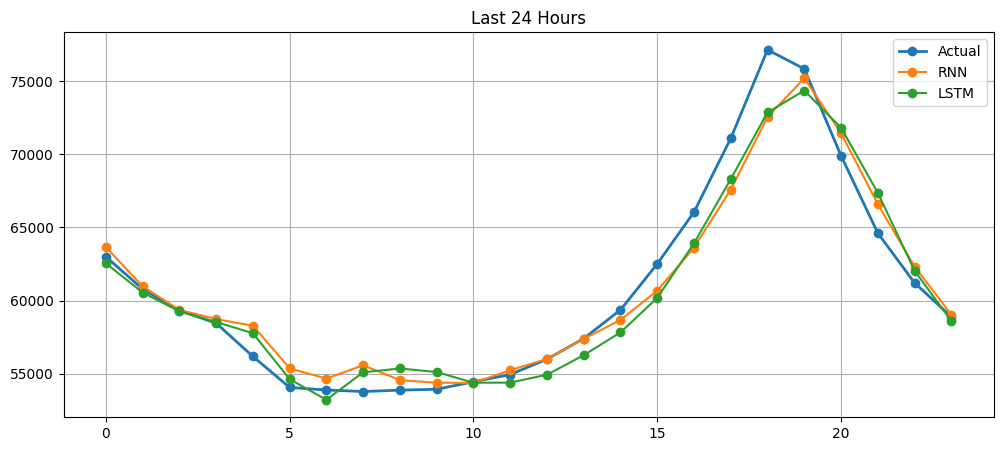

In [89]:
plt.figure(figsize=(12,5))

plt.plot(
    actual_lstm[-24:],
    marker='o',
    linewidth=2,
    label='Actual'
)

plt.plot(
    rnn_preds[-24:],
    marker='o',
    label='RNN'
)

plt.plot(
    lstm_preds[-24:],
    marker='o',
    label='LSTM'
)

plt.title("Last 24 Hours")
plt.legend()
plt.grid(True)

plt.show()

In [101]:
import pandas as pd
import numpy as np

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# ==========================================================
# 1. Load electricity demand data
# ==========================================================

df_full = pd.read_csv("energy_demand_hourly_brazil.csv")
df_full["index"] = pd.to_datetime(df_full["index"])

# ==========================================================
# 2. Remove Brazilian electricity crisis period
#    (15 May 2001 - 15 Feb 2002)
# ==========================================================

clean_df = df_full[
    ~(
        (df_full["index"] >= "2001-05-15") &
        (df_full["index"] <= "2002-02-15")
    )
].copy()

clean_df = clean_df.reset_index(drop=True)

# ==========================================================
# 3. Replace zero demand values
# ==========================================================

clean_df["hourly_demand"] = (
    clean_df["hourly_demand"]
    .replace(0, np.nan)
    .interpolate(method="linear")
    .bfill()
    .ffill()
)

# ==========================================================
# 4. Create continuous hourly time index
# ==========================================================

clean_df["time"] = pd.date_range(
    start="2000-01-01",
    periods=len(clean_df),
    freq="h"
)

# ==========================================================
# 5. Merge weather data
# (weather dataframe should already be loaded)
# ==========================================================

merged_clean = pd.merge(
    clean_df,
    weather,
    on="time",
    how="inner"
)

# ==========================================================
# 6. Train-Test Split
# ==========================================================

H = 24

train = merged_clean.iloc[:-H]
test = merged_clean.iloc[-H:]

# ==========================================================
# 7. Exogenous Variable
# ==========================================================

exog_cols = ["temperature_2m"]

train_exog = train[exog_cols]
test_exog = test[exog_cols]

# ==========================================================
# 8. Rolling Window (Last 90 Days)
# ==========================================================

VENTANA = 24 * 90

train_window = train["hourly_demand"].iloc[-(VENTANA + H):-H]

train_exog_window = train_exog.iloc[-(VENTANA + H):-H]

test_exog_window = train_exog.iloc[-H:]

# ==========================================================
# 9. SARIMA
# ==========================================================

sarima_model = SARIMAX(
    train_window,
    order=(1,0,2),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)

sarima_forecast = sarima_results.forecast(
    steps=H
)

# ==========================================================
# 10. SARIMAX (Apparent Temperature)
# ==========================================================

sarimax_model = SARIMAX(
    train_window,
    exog=train_exog_window,
    order=(1,0,2),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)

sarimax_forecast = sarimax_results.forecast(
    steps=H,
    exog=test_exog_window
)

# ==========================================================
# 11. Evaluation
# ==========================================================

actual = test["hourly_demand"]

sarima_mae = mean_absolute_error(actual, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(actual, sarima_forecast))
sarima_mape = mean_absolute_percentage_error(actual, sarima_forecast)

sarimax_mae = mean_absolute_error(actual, sarimax_forecast)
sarimax_rmse = np.sqrt(mean_squared_error(actual, sarimax_forecast))
sarimax_mape = mean_absolute_percentage_error(actual, sarimax_forecast)

# ==========================================================
# 12. Results
# ==========================================================

print("=" * 55)
print("SARIMA")
print("=" * 55)
print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape*100:.2f}%")

print()

print("=" * 55)
print("SARIMAX (Apparent Temperature)")
print("=" * 55)
print(f"MAE  : {sarimax_mae:.2f}")
print(f"RMSE : {sarimax_rmse:.2f}")
print(f"MAPE : {sarimax_mape*100:.2f}%")

SARIMA
MAE  : 5514.96
RMSE : 6261.86
MAPE : 9.55%

SARIMAX (Apparent Temperature)
MAE  : 6982.13
RMSE : 7838.52
MAPE : 11.76%
